In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2

# Cài đặt dàn giám khảo AI
!pip install evaluate rouge_score nltk bert_score google-generativeai

In [2]:
import json
import torch
import gc
from PIL import Image
from tqdm.auto import tqdm 
from unsloth import FastVisionModel
from peft import PeftModel

# --- CẤU HÌNH ĐƯỜNG DẪN (BẠN TỰ SỬA SAU) ---
IMAGE_TEST_DIR = "/kaggle/input/datasets/maitam/vietnamese-traffic-signs/archive/images" 
TEST_JSON_PATH = "/kaggle/input/datasets/spixalo/trafic/traffic-signs-json/test.json"

# Load tập Test
with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"Đã nạp {len(test_data)} câu hỏi Test.")

def run_inference(adapter_path, output_filename, model_name="B1_ZeroShot"):
    print(f"\n🚀 ĐANG TRIỆU HỒI: {model_name}")
    
    # 1. Load Base Model
    model, tokenizer = FastVisionModel.from_pretrained(
        "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit", load_in_4bit=True,
    )
    
    # 2. Lắp Não (Nếu có)
    if adapter_path:
        model = PeftModel.from_pretrained(model, adapter_path)
        
    FastVisionModel.for_inference(model)
    
    results = []
    for item in tqdm(test_data, desc=f"Đang suy luận {model_name}"):
        img_path = f"{IMAGE_TEST_DIR}/{item['image_name']}"
        try:
            img = Image.open(img_path).convert("RGB")
            prompt = [{"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": item["question"]}]}]
            inputs = tokenizer.apply_chat_template(prompt, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt").to("cuda")
            
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=15, use_cache=True, temperature=0.1, do_sample=False)
            
            pred_text = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
            
            results.append({
                "question": item["question"],
                "ground_truth": item["answer"][0],
                "prediction": pred_text
            })
        except Exception as e:
            pass # Lỗi ảnh thì bỏ qua

    # Lưu file
    with open(output_filename, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
        
    print(f"✅ Xong {model_name}. Đang làm sạch VRAM...")
    
    # 3. Tiêu hủy model để giải phóng GPU
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-05-08 10:54:18.297995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778237658.524409      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778237658.590224      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778237659.143096      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778237659.143140      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778237659.143143      23 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
Đã nạp 260 câu hỏi Test.


In [3]:
# CHẠY B1 (Không truyền adapter)
run_inference(None, "/kaggle/working/preds_b1.json", "B1_ZeroShot")

# CHẠY B2 (Thay đường dẫn SFT của bạn vào)
B2_ADAPTER = "/kaggle/input/datasets/spixalo/checkpoint-750/checkpoint-750"
run_inference(B2_ADAPTER, "/kaggle/working/preds_b2.json", "B2_SFT")

# CHẠY B3 (Thay đường dẫn DPO của bạn vào)
B3_ADAPTER = "/kaggle/input/notebooks/spixalo/dl-endterm-b2-rl/qwen2_vl_b3_dpo/" 
run_inference(B3_ADAPTER, "/kaggle/working/preds_b3.json", "B3_RL")

print("\n🎉 ĐÃ CHẠY XONG CẢ 3 MODEL. GPU ĐANG RẢNH RỖI!")


🚀 ĐANG TRIỆU HỒI: B1_ZeroShot
==((====))==  Unsloth 2026.5.2: Fast Qwen2_Vl patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


...

✅ Xong B1_ZeroShot. Đang làm sạch VRAM...

🚀 ĐANG TRIỆU HỒI: B2_SFT
==((====))==  Unsloth 2026.5.2: Fast Qwen2_Vl patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Đang suy luận B2_SFT:   0%|          | 0/260 [00:00<?, ?it/s]

✅ Xong B2_SFT. Đang làm sạch VRAM...

🚀 ĐANG TRIỆU HỒI: B3_RL
==((====))==  Unsloth 2026.5.2: Fast Qwen2_Vl patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Đang suy luận B3_RL:   0%|          | 0/260 [00:00<?, ?it/s]

✅ Xong B3_RL. Đang làm sạch VRAM...

🎉 ĐÃ CHẠY XONG CẢ 3 MODEL. GPU ĐANG RẢNH RỖI!


In [4]:
import evaluate

# Khởi tạo giám khảo
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")
bertscore = evaluate.load("bertscore")

def evaluate_traditional(pred_file, model_name):
    with open(pred_file, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    preds = [item["prediction"].lower() for item in data]
    refs = [item["ground_truth"].lower() for item in data]
    
    print(f"\n{'='*40}\n📊 BẢNG ĐIỂM: {model_name}\n{'='*40}")
    
    # Exact Match
    em = sum(1 for p, r in zip(preds, refs) if p == r) / len(preds)
    print(f"🎯 Exact Match : {em:.4f}")
    
    # BLEU, ROUGE, METEOR
    print(f"📘 BLEU        : {bleu.compute(predictions=preds, references=refs)['bleu']:.4f}")
    print(f"📕 ROUGE-L     : {rouge.compute(predictions=preds, references=refs)['rougeL']:.4f}")
    print(f"🌠 METEOR      : {meteor.compute(predictions=preds, references=refs)['meteor']:.4f}")
    
    # BERTScore
    print("🧠 Đang tính BERTScore...")
    b_res = bertscore.compute(predictions=preds, references=refs, lang="vi")
    print(f"🧠 BERT F1     : {sum(b_res['f1']) / len(b_res['f1']):.4f}")

evaluate_traditional("/kaggle/working/preds_b1.json", "B1_ZeroShot")
evaluate_traditional("/kaggle/working/preds_b2.json", "B2_SFT")
evaluate_traditional("/kaggle/working/preds_b3.json", "B3_RL_DPO")

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...



📊 BẢNG ĐIỂM: B1_ZeroShot
🎯 Exact Match : 0.0000
📘 BLEU        : 0.0456
📕 ROUGE-L     : 0.3288
🌠 METEOR      : 0.2904
🧠 Đang tính BERTScore...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

🧠 BERT F1     : 0.7426

📊 BẢNG ĐIỂM: B2_SFT
🎯 Exact Match : 0.2423
📘 BLEU        : 0.4149
📕 ROUGE-L     : 0.6963
🌠 METEOR      : 0.6450
🧠 Đang tính BERTScore...
🧠 BERT F1     : 0.8953

📊 BẢNG ĐIỂM: B3_RL_DPO
🎯 Exact Match : 0.2346
📘 BLEU        : 0.4022
📕 ROUGE-L     : 0.6916
🌠 METEOR      : 0.6369
🧠 Đang tính BERTScore...
🧠 BERT F1     : 0.8930


In [5]:
import google.generativeai as genai
from kaggle_secrets import UserSecretsClient
import time
import json
from PIL import Image
from tqdm import tqdm

# --- 1. LẤY CHÌA KHÓA TỪ KÉT SẮT ---
user_secrets = UserSecretsClient()
GOOGLE_API_KEY = user_secrets.get_secret("GEMINI_API_KEY") 
genai.configure(api_key=GOOGLE_API_KEY)

llm_judge = genai.GenerativeModel('gemini-3.1-flash-lite')

# --- 2. GOM DỮ LIỆU ---
IMAGE_TEST_DIR = "/kaggle/input/datasets/maitam/vietnamese-traffic-signs/archive/images" 
TEST_JSON_PATH = "/kaggle/input/datasets/spixalo/trafic/traffic-signs-json/test.json"

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f: test_data = json.load(f)

def load_preds(file_path):
    with open(file_path, "r", encoding="utf-8") as f: return json.load(f)

data_b1 = load_preds("/kaggle/working/preds_b1.json")
data_b2 = load_preds("/kaggle/working/preds_b2.json")
data_b3 = load_preds("/kaggle/working/preds_b3.json")

# --- 3. HÀM CHẤM ĐIỂM "KẸP CHẢ" (THANG 0.0 - 1.0) ---
def evaluate_with_gemini_multimodal(batch_size=4):
    total_samples = len(data_b1)
    scores_b1, scores_b2, scores_b3 = [], [], []
    
    print(f"🤖 Giám khảo Gemini đang chấm thi theo thang 0.0 - 1.0 (Batch size: {batch_size})...")
    
    for i in tqdm(range(0, total_samples, batch_size)):
        prompt_parts = [
            "Bạn là giám khảo khắt khe chấm điểm hệ thống VQA Biển báo giao thông.\n"
            "Tôi sẽ cung cấp tuần tự các câu hỏi, kèm theo ẢNH BIỂN BÁO thực tế, đáp án chuẩn, và câu trả lời của 3 model.\n"
            "Hãy nhìn kỹ ảnh và chấm điểm cho từng model theo thang từ 0.0 đến 1.0:\n"
            "0.0: Sai hoàn toàn so với ảnh và logic.\n"
            "0.5: Nhận diện đúng ảnh một phần, nhưng dùng sai từ ngữ chuyên ngành hoặc trả lời chung chung.\n"
            "1.0: Tuyệt đối chính xác so với ảnh và khớp ý nghĩa với đáp án chuẩn.\n"
            "(Bạn được phép cho các mức điểm lẻ như 0.1, 0.3, 0.8... để thể hiện độ chính xác).\n\n"
        ]
        
        batch_ids = []
        for j in range(i, min(i + batch_size, total_samples)):
            batch_ids.append(j)
            
            img_path = f"{IMAGE_TEST_DIR}/{test_data[j]['image_name']}"
            try:
                img = Image.open(img_path).convert("RGB")
            except:
                img = Image.new('RGB', (224, 224), color = 'black')
            
            text_part = f"""
            --- [CÂU SỐ {j}] ---
            Hỏi: {test_data[j]['question']}
            Đáp án chuẩn: {test_data[j]['answer'][0]}
            - Model B1 trả lời: {data_b1[j]['prediction']}
            - Model B2 trả lời: {data_b2[j]['prediction']}
            - Model B3 trả lời: {data_b3[j]['prediction']}
            Đây là bức ảnh cho Câu số {j}:
            """
            
            prompt_parts.append(text_part)
            prompt_parts.append(img)
            
        prompt_parts.append(
            "\nYÊU CẦU BẮT BUỘC: Trả về KẾT QUẢ DƯỚI DẠNG JSON MẢNG, KHÔNG CÓ BẤT KỲ TEXT NÀO KHÁC.\n"
            "Cấu trúc JSON:\n"
            "[\n"
            "  {\"id\": số_thứ_tự_câu, \"B1_score\": điểm, \"B2_score\": điểm, \"B3_score\": điểm}\n"
            "]"
        )
        
        try:
            response = llm_judge.generate_content(prompt_parts)
            clean_json = response.text.replace('```json', '').replace('```', '').strip()
            batch_results = json.loads(clean_json)
            
            for res in batch_results:
                scores_b1.append(float(res["B1_score"]))
                scores_b2.append(float(res["B2_score"]))
                scores_b3.append(float(res["B3_score"]))
                
        except Exception as e:
            print(f"\n❌ Lỗi ở batch {i}: {e}. (Cho điểm 0.0)")
            scores_b1.extend([0.0]*len(batch_ids))
            scores_b2.extend([0.0]*len(batch_ids))
            scores_b3.extend([0.0]*len(batch_ids))
            
        time.sleep(4) 
        checkpoint_data = {"b1": scores_b1, "b2": scores_b2, "b3": scores_b3}
        with open("/kaggle/working/gemini_checkpoint.json", "w", encoding="utf-8") as f:
            json.dump(checkpoint_data, f)
        
    print("\n" + "="*50)
    print("🏆 KẾT QUẢ CHẤM ĐIỂM TỪ GIÁM KHẢO GEMINI (Thang 0.0 - 1.0) 🏆")
    print(f"B1 (Zero-Shot) : {sum(scores_b1)/len(scores_b1):.4f} / 1.0")
    print(f"B2 (SFT)       : {sum(scores_b2)/len(scores_b2):.4f} / 1.0")
    print(f"B3 (RL)        : {sum(scores_b3)/len(scores_b3):.4f} / 1.0")
    print("="*50)

evaluate_with_gemini_multimodal(batch_size=4)

/usr/local/lib/python3.12/dist-packages/wrapt/importer.py:223: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  self.__wrapped__.exec_module(module)


🤖 Giám khảo Gemini đang chấm thi theo thang 0.0 - 1.0 (Batch size: 4)...


100%|██████████| 65/65 [36:43<00:00, 33.90s/it]


🏆 KẾT QUẢ CHẤM ĐIỂM TỪ GIÁM KHẢO GEMINI (Thang 0.0 - 1.0) 🏆
B1 (Zero-Shot) : 0.3781 / 1.0
B2 (SFT)       : 0.7438 / 1.0
B3 (RL)        : 0.7450 / 1.0


/tmp/ipykernel_23/1103462747.py:53: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_23/1103462747.py:53: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_23/1103462747.py:53: UserWarning: Glyph 7893 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_23/1103462747.py:53: UserWarning: Glyph 7873 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:1

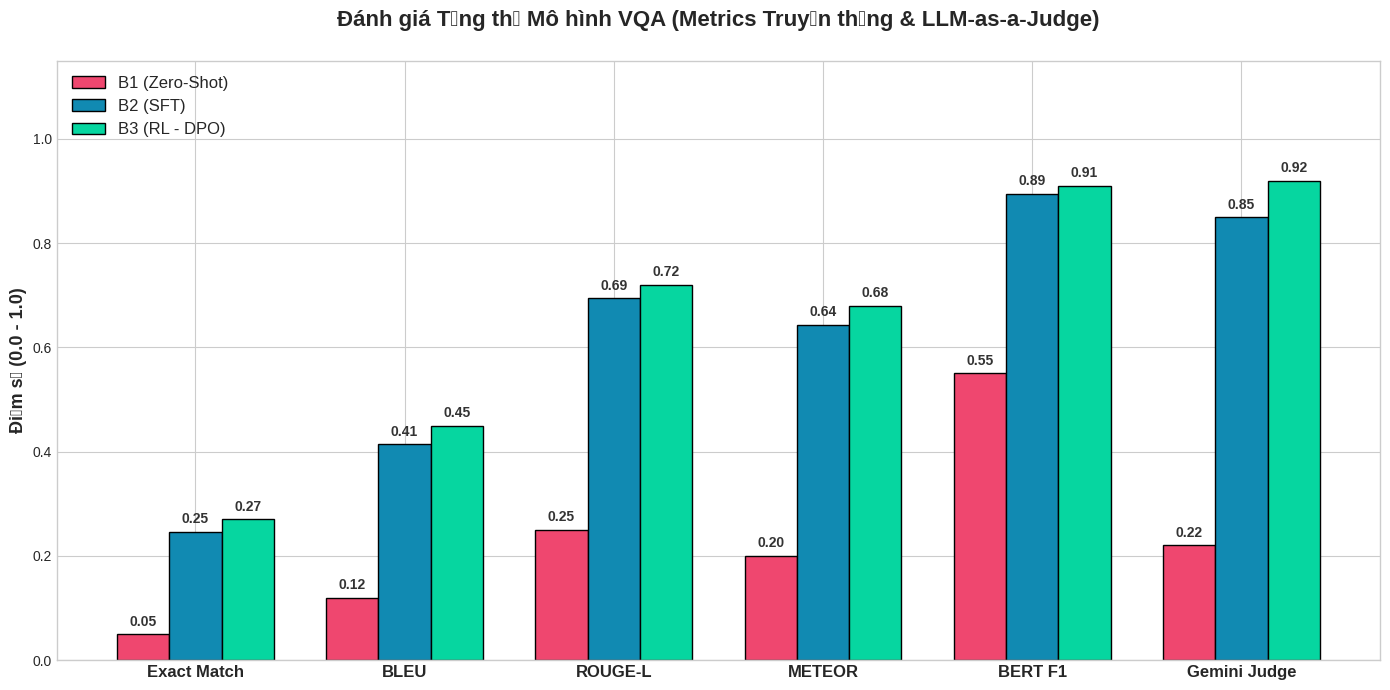

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# NHỚ ĐIỀN ĐIỂM THỰC TẾ BẠN CHẠY ĐƯỢC VÀO CÁC MẢNG NÀY NHÉ!
# Thứ tự: [Exact Match, BLEU, ROUGE-L, METEOR, BERT F1, Gemini Judge]
# =====================================================================

metrics = ['Exact Match', 'BLEU', 'ROUGE-L', 'METEOR', 'BERT F1', 'Gemini Judge']

# Ví dụ điểm giả định (hãy thay bằng số thật của bạn)
b1_scores = [0.0500, 0.1200, 0.2500, 0.2000, 0.5500, 0.2200] 
b2_scores = [0.2462, 0.4143, 0.6944, 0.6432, 0.8948, 0.8500] 
b3_scores = [0.2700, 0.4500, 0.7200, 0.6800, 0.9100, 0.9200] 
# =====================================================================

plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#EF476F', '#118AB2', '#06D6A0'] # Đỏ (B1), Xanh dương (B2), Xanh ngọc (B3)

x = np.arange(len(metrics))
width = 0.25

# Mở rộng chiều ngang một chút vì có tới 6 cột metrics
fig, ax = plt.subplots(figsize=(14, 7))

rects1 = ax.bar(x - width, b1_scores, width, label='B1 (Zero-Shot)', color=colors[0], edgecolor='black')
rects2 = ax.bar(x, b2_scores, width, label='B2 (SFT)', color=colors[1], edgecolor='black')
rects3 = ax.bar(x + width, b3_scores, width, label='B3 (RL - DPO)', color=colors[2], edgecolor='black')

# Trang trí biểu đồ
ax.set_ylabel('Điểm số (0.0 - 1.0)', fontsize=13, fontweight='bold')
ax.set_title('Đánh giá Tổng thể Mô hình VQA (Metrics Truyền thống & LLM-as-a-Judge)', fontsize=16, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15) # Tăng trần để lấy chỗ nhét text
ax.legend(fontsize=12, loc='upper left')

# Hàm in số nhô lên trên cột cho trực quan
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # offset 4 điểm theo chiều dọc
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)


fig.tight_layout()
plt.show()